In [1]:
# Plot light curve and phase diagram

import matplotlib.pyplot as plt
import numpy as np
from astropy.timeseries import LombScargle
# from scipy import stats
# from scipy.stats import distributions
# import similaritymeasures

In [2]:
#Choose data path

path = '/media/fernando/KINGSTON/Doutorado/2025/reduced/'
date = '20250706'
object = 'V2400Oph'
channel = '1'
source = '6'

data = f'{path}{date}/export_txt'

In [3]:
#   Reading polarimetry data

data1 = np.loadtxt(f'{data}/{object}_ch{channel}_SRC{source}_polar.txt',skiprows=1)

t1=data1[:,0]
mag1=data1[:,10]
mag1_error=data1[:,11]

In [4]:
# Removendo a media dos dados

mag_mean1=np.mean(mag1)
mag_c1=mag1-mag_mean1
#mag_c1=mag1

In [5]:
#data1 = np.loadtxt('11bocet_pol.txt',skiprows=0)

#t2=data1[:,0]
#mag2=data1[:,1]
#mag2_error=data1[:,2]

In [6]:
# Removendo a media dos dados
#
#mag_mean2=np.mean(mag2)
#mag_c2=mag2-mag_mean2
#mag_c2=mag2

In [7]:
#data1 = np.loadtxt('12bocet_pol.txt',skiprows=0)

#t3=data1[:,0]
#mag3=data1[:,1]
#mag3_error=data1[:,2]

In [8]:
# Removendo a media dos dados

#mag_mean3=np.mean(mag3)
#mag_c3=mag3-mag_mean3
#mag_c3=mag3

In [9]:
#data1 = np.loadtxt('19bocet_pol.txt',skiprows=0)

#t4=data1[:,0]
#mag4=data1[:,1]
#mag4_error=data1[:,2]

In [10]:
# Removendo a media dos dados
#
#mag_mean4=np.mean(mag4)
#mag_c4=mag4-mag_mean4
#mag_c4=mag4

In [11]:
time=t1
mag_c=mag_c1
mag_error=mag1_error
#time=np.concatenate((t1,t2,t3,t4))
#mag_c=np.concatenate((mag_c1,mag_c2,mag_c3,mag_c4))
#mag_error=np.concatenate((mag1_error,mag2_error,mag3_error,mag4_error))
# time=1.*t1
# mag_c=1.*mag_c1
# mag_error=1.*mag1_error

In [12]:
#  Filter data
#
filter="no"
# filter="yes"

In [13]:
##### Lomb Scargle
#
# limites em minutos
p1=5.
p2=200.
# 
p1=p1/60./24.0
p2=p2/60./24.0
# 
# limites em dias
# p1=0.
# p2=1.
#
#
# Numero de frequencias
#
n_freq=int(1e6)
frequency = np.linspace(1./p2, 1./p1, n_freq)

In [14]:
#  Fazendo o Lomb-Scargle
#
#ls = LombScargle(time, mag_c)
ls = LombScargle(time, mag_c,mag_error)
power = ls.power(frequency)
probabilities = [0.001]
fap=ls.false_alarm_level(probabilities) 
#
best_frequency = frequency[np.argmax(power)]
best_period=1./best_frequency
print(' ')
print('Best period in days  ', best_period)
print('Best period in hours  ', best_period*24.)
print('Best period in minutes  ', best_period*24.*60.)
print('False alarm probability of 0.001  ',fap)
print(' ')

 
Best period in days   0.004649339594683336
Best period in hours   0.11158415027240007
Best period in minutes   6.695049016344004
False alarm probability of 0.001   [0.05396319]
 


In [15]:
best_period*60*24

np.float64(6.695049016344004)

In [16]:
927/60

15.45

In [17]:
((927.66/60)/60)/24

0.010736805555555555

In [18]:
#best_period=((927.66/60)/60)/24

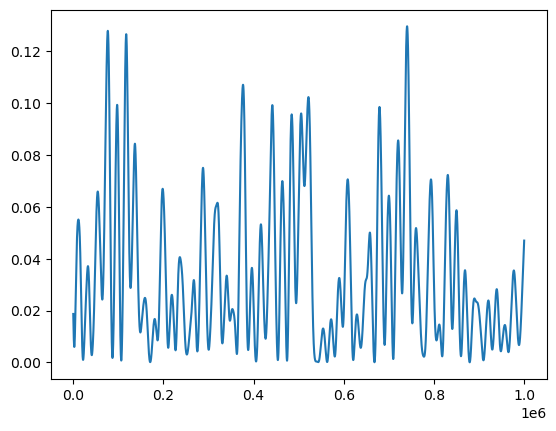

In [19]:
plt.plot(power)

In [20]:
# Calculando phase diagram
#
to=2460863.42808605
phase=((time-to)%best_period)/best_period

In [21]:
phase

array([3.21289630e-01, 4.02570284e-01, 4.83730050e-01, 5.64998285e-01,
       6.46217844e-01, 7.27227074e-01, 8.08313425e-01, 8.89638949e-01,
       9.70874733e-01, 5.26332338e-02, 1.33940029e-01, 2.15032589e-01,
       2.96303228e-01, 3.77427037e-01, 4.58827178e-01, 5.39963307e-01,
       6.21566364e-01, 7.02678856e-01, 7.83787742e-01, 8.65257592e-01,
       9.46458421e-01, 2.76321086e-02, 1.08809201e-01, 1.89779971e-01,
       2.71040594e-01, 3.52604992e-01, 4.34072237e-01, 5.15097793e-01,
       5.96185446e-01, 6.77330388e-01, 7.58446686e-01, 8.39890194e-01,
       9.21399806e-01, 2.80615693e-03, 8.38028677e-02, 1.64990176e-01,
       2.46138924e-01, 3.27252718e-01, 4.08530768e-01, 4.89711767e-01,
       5.70943945e-01, 6.52399974e-01, 7.33638161e-01, 8.14751955e-01,
       8.95884478e-01, 9.77013195e-01, 5.84231511e-02, 1.39660337e-01,
       2.20979452e-01, 3.02124394e-01, 3.83547972e-01, 4.64686704e-01,
       5.45957443e-01, 6.27235393e-01, 7.08341975e-01, 7.89519068e-01,
      

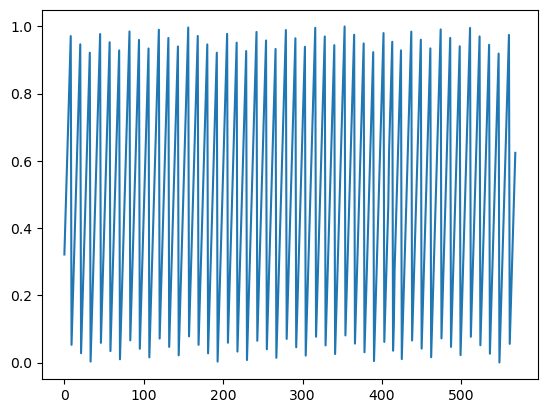

In [22]:
plt.plot(phase)

In [23]:
# Binning data in the best period
#
number_bins=6
center_bin=np.zeros(number_bins)
bin_means=np.zeros(number_bins)
bin_size=1./number_bins
bins = np.linspace(0, 1, number_bins+1)
digitized = np.digitize(phase, bins)
# print(bins)
# print(digitized)

In [24]:
number_bins

6

In [25]:
center_bin

array([0., 0., 0., 0., 0., 0.])

In [26]:
bin_means

array([0., 0., 0., 0., 0., 0.])

In [27]:
bin_size

0.16666666666666666

In [28]:
bins

array([0.        , 0.16666667, 0.33333333, 0.5       , 0.66666667,
       0.83333333, 1.        ])

In [29]:
digitized

array([2, 3, 3, 4, 4, 5, 5, 6, 6, 1, 1, 2, 2, 3, 3, 4, 4, 5, 5, 6, 6, 1,
       1, 2, 2, 3, 3, 4, 4, 5, 5, 6, 6, 1, 1, 1, 2, 2, 3, 3, 4, 4, 5, 5,
       6, 6, 1, 1, 2, 2, 3, 3, 4, 4, 5, 5, 6, 6, 1, 1, 2, 2, 3, 3, 4, 4,
       5, 5, 6, 6, 1, 1, 2, 2, 3, 3, 3, 4, 4, 5, 5, 6, 6, 1, 1, 2, 2, 3,
       3, 4, 4, 5, 5, 6, 6, 1, 1, 2, 2, 3, 3, 4, 4, 5, 5, 6, 6, 1, 1, 2,
       2, 3, 3, 4, 4, 4, 5, 5, 6, 6, 1, 1, 2, 2, 3, 3, 4, 4, 5, 5, 6, 6,
       1, 1, 2, 2, 3, 3, 4, 4, 5, 5, 6, 6, 1, 1, 2, 2, 3, 3, 4, 4, 5, 5,
       6, 6, 6, 1, 1, 2, 2, 3, 3, 4, 4, 5, 5, 6, 6, 1, 1, 2, 2, 3, 3, 4,
       4, 5, 5, 6, 6, 1, 1, 2, 2, 3, 3, 4, 4, 5, 5, 6, 6, 1, 1, 1, 2, 2,
       3, 3, 4, 4, 5, 5, 6, 6, 1, 1, 2, 2, 3, 3, 4, 4, 5, 5, 6, 6, 1, 1,
       2, 2, 3, 3, 4, 4, 5, 5, 6, 6, 1, 1, 2, 2, 2, 3, 3, 4, 4, 5, 5, 6,
       6, 1, 1, 2, 2, 3, 3, 4, 4, 5, 5, 6, 6, 1, 1, 2, 2, 3, 3, 4, 4, 5,
       5, 6, 6, 1, 1, 2, 2, 3, 3, 4, 4, 4, 5, 5, 6, 6, 1, 1, 2, 2, 3, 3,
       4, 4, 5, 5, 6, 6, 1, 1, 2, 2, 3, 3, 4, 4, 5,

In [30]:
for i in range(1, len(bins)):
    im=i-1
    center_bin[im]=bins[i]-0.5*bin_size
    bin_means[im]=np.mean(mag_c[digitized == i])
    print(i,center_bin[im],bin_means[im]) 
#
#    Model sinuosoidal
# 
y_fit = ls.model(time, best_frequency)

1 0.08333333333333333 0.00034652139774488886
2 0.25 0.0009688052613955047
3 0.4166666666666667 -3.929193228800591e-05
4 0.5833333333333333 -0.0005434661427046727
5 0.7499999999999999 -0.0004917400226470485
6 0.9166666666666666 -0.00023211585137045278


In [31]:
mag_c

array([ 5.62141441e-03,  2.01113861e-03,  2.53234951e-03, -1.81938219e-03,
       -2.99439699e-03, -8.25684149e-03, -7.39892139e-03, -6.80139509e-03,
       -7.43422949e-03, -7.26548409e-03, -6.05803179e-03, -5.57596699e-03,
       -4.38030659e-03, -1.94625109e-03, -3.30848979e-03, -8.38905949e-03,
       -5.53311279e-03, -4.62543879e-03, -4.76392879e-03, -1.17190119e-03,
       -1.58551419e-03,  1.02742221e-03,  1.66112711e-03,  2.26059761e-03,
        2.29705931e-03,  3.05369315e-04,  1.87749915e-04, -2.94041439e-03,
       -6.61002209e-03, -7.99760649e-03, -8.26413559e-03, -7.88369649e-03,
       -6.63937209e-03, -4.67841509e-03, -4.55942839e-03, -2.56220919e-03,
       -1.21482854e-05, -4.00013685e-04, -2.31365579e-03,  4.67418951e-03,
        5.75408921e-03,  5.51257881e-03,  5.62688201e-03, -2.46453109e-03,
       -3.64278279e-03, -6.12038519e-03, -2.58850449e-03, -1.29432759e-03,
        3.37036701e-03,  3.34588811e-03, -3.45796899e-03,  1.85299015e-04,
        1.22816101e-03,  

In [32]:
len(mag_c)

569

In [33]:
mag_c[digitized==1]

array([-7.26548409e-03, -6.05803179e-03,  1.02742221e-03,  1.66112711e-03,
       -4.67841509e-03, -4.55942839e-03, -2.56220919e-03, -2.58850449e-03,
       -1.29432759e-03, -1.29293285e-04, -1.20166429e-03,  6.82724315e-04,
        1.91662971e-03, -3.57397019e-03, -2.60220659e-03,  1.66329081e-03,
        1.10372715e-04,  5.44497515e-04,  6.14638415e-04, -2.88334069e-03,
       -4.54714619e-03,  3.61705541e-03,  4.97095481e-03, -3.70243739e-03,
        3.94672315e-04, -1.68517189e-03, -2.15056869e-03, -2.67521359e-03,
       -1.01229119e-03,  1.22518891e-03,  8.42941715e-04, -3.47544649e-03,
       -4.02985019e-03, -6.77512269e-03,  6.98302891e-03,  8.22646671e-03,
        4.12323021e-03,  1.35950001e-03,  5.41777691e-03,  5.61607971e-03,
        1.89982801e-03, -1.63970559e-03,  3.50509921e-03,  3.61256361e-03,
       -2.35074749e-03, -2.28569219e-03,  5.58244621e-03, -2.87749249e-03,
       -2.73286509e-03, -2.57854449e-03,  2.77725011e-03,  1.84531371e-03,
        4.17723661e-03,  

In [34]:
bin_means

array([ 3.46521398e-04,  9.68805261e-04, -3.92919323e-05, -5.43466143e-04,
       -4.91740023e-04, -2.32115851e-04])

In [35]:
y_fit

array([ 1.91816770e-03,  1.39984506e-03,  4.88595481e-04, -5.85527528e-04,
       -1.54700516e-03, -2.15050936e-03, -2.24561441e-03, -1.80538438e-03,
       -9.42318318e-04,  1.30702170e-04,  1.12747973e-03,  1.79792189e-03,
        1.97433430e-03,  1.61090808e-03,  7.97526740e-04, -2.53782427e-04,
       -1.28294491e-03, -2.01656042e-03, -2.27472500e-03, -1.98945790e-03,
       -1.23467470e-03, -2.02939558e-04,  8.43351812e-04,  1.63630783e-03,
        1.97810145e-03,  1.77637356e-03,  1.08179134e-03,  7.83720919e-05,
       -9.82696306e-04, -1.83167976e-03, -2.25180981e-03, -2.13509100e-03,
       -1.50806975e-03, -5.32871199e-04,  5.36188153e-04,  1.43407551e-03,
        1.92954717e-03,  1.89718109e-03,  1.34394820e-03,  4.11785995e-04,
       -6.63022110e-04, -1.60819680e-03, -2.17775738e-03, -2.22967013e-03,
       -1.75178515e-03, -8.65594562e-04,  2.07295064e-04,  1.18796689e-03,
        1.82900306e-03,  1.96587853e-03,  1.56337260e-03,  7.26639294e-04,
       -3.33765200e-04, -

In [36]:
len(y_fit)

569

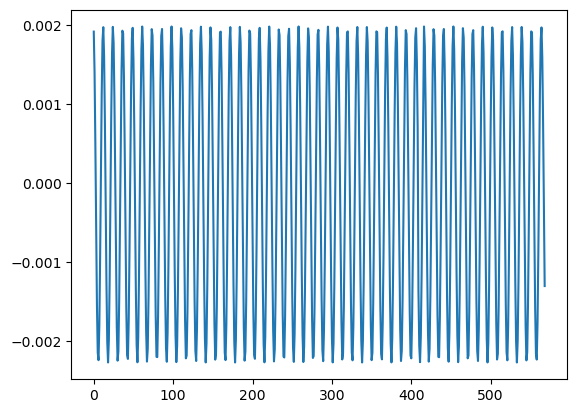

In [37]:
plt.plot(y_fit)

In [38]:
# Filtrando
#
if (filter != "no"):
	f= open("bocet_fot_p1_509.txt","x")
	mag_filtered=np.zeros(len(mag_c))
	for i in range(0, len(mag_c)):
#
#    Aqui eu filtro por media do bin - nao eh bom
#
# 		mag_filtered[i]=mag[i]-bin_means[digitized[i]-1]
#  
#    Aqui filtro por Model sinuosoidal
# 
		mag_filtered[i]=mag_c[i]-y_fit[i]
		f.write(f"{time[i]} {mag_c[i]} {mag_filtered[i]} \n")
	
#
	f.close()

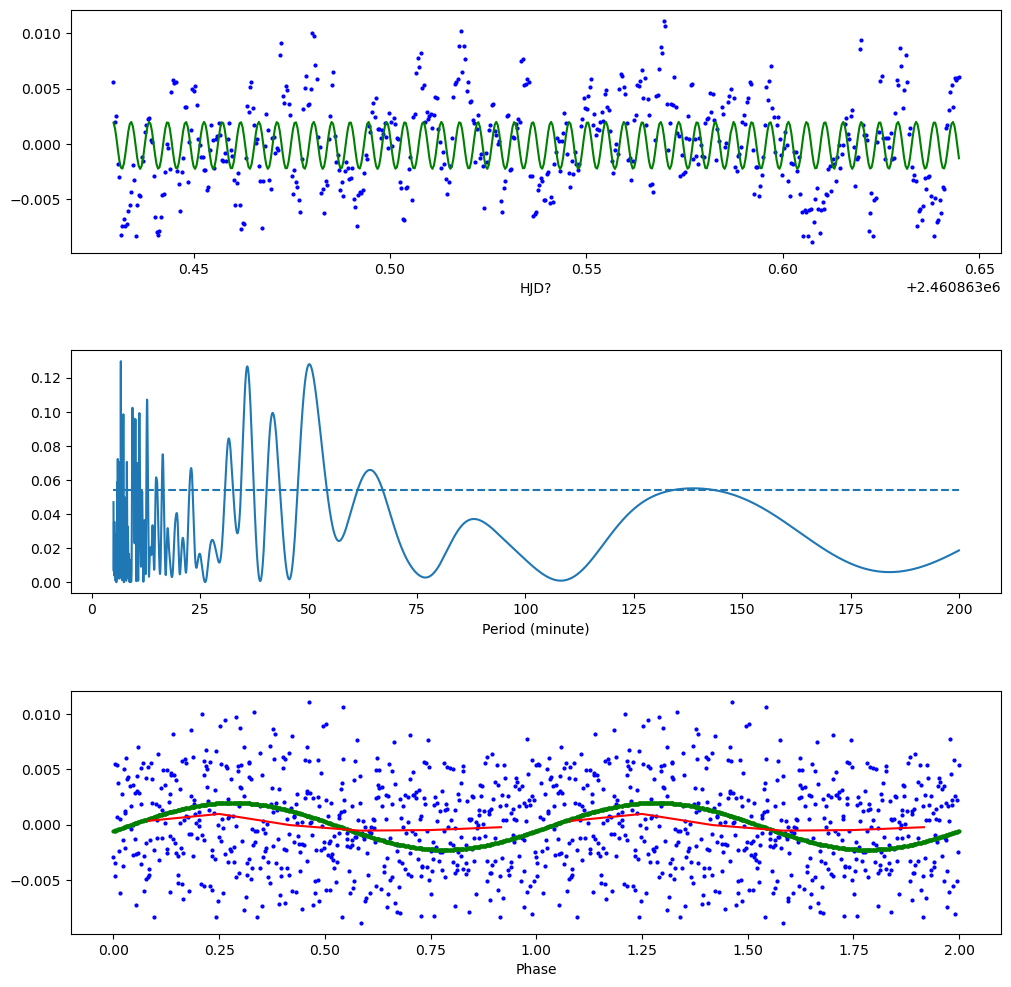

In [39]:
#### Plot

plt.close('all')

#f, ax = plt.subplots(2, sharex=True)
f, ax = plt.subplots(3, figsize=(12, 12), sharex=False)
f.subplots_adjust(hspace=0.4)
#f.align_ylabels(ax[0:1])

ax[0].plot(time,mag_c,'b.',markersize=4)
ax[0].plot(time,y_fit,'g-',markersize=4)
ax[0].set_xlabel('HJD?')
# ax[0].set_xlim(52455.2,52455.4)

ax[1].plot(1./frequency*24.*60.,power)
ax[1].set_xlabel('Period (minute)')
xmin=p1*24.*60.
xmax=p2*24.*60.
# ax[1].plot(1./frequency,power)
# ax[1].set_xlabel('Period (d)')
# xmin=p1
# xmax=p2
ax[1].hlines(fap,xmin,xmax,linestyles='dashed')

ax[2].plot(phase,mag_c,'b.',markersize=4)
ax[2].plot(phase+1.0,mag_c,'b.',markersize=4)
ax[2].plot(phase,y_fit,'g.',markersize=4)
ax[2].plot(phase+1.0,y_fit,'g.',markersize=4)
ax[2].plot(center_bin,bin_means,'r-',markersize=4)
ax[2].plot(center_bin+1.0,bin_means,'r-',markersize=4)
ax[2].set_xlabel('Phase')
# ax[2].set_xlim(0,2)
#ax[2].plot(t_fit,y_fit,'k-')

# print(time.size)
# print(time_b.size)
# print(time_v.size)
plt.show()